## Grupp4

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, make_scorer
import seaborn as sns

# Ladda data
df = pd.read_csv('historical_data.csv')


EDA

In [17]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  object 
 3   category                    12000 non-null  object 
 4   region                      11660 non-null  object 
 5   device                      12000 non-null  object 
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  contains_off_platform       120

In [18]:
target_counts = df['is_suspicious'].value_counts(normalize=True)
print(f"Fördelning:\n{target_counts}")

Fördelning:
is_suspicious
0    0.898
1    0.102
Name: proportion, dtype: float64


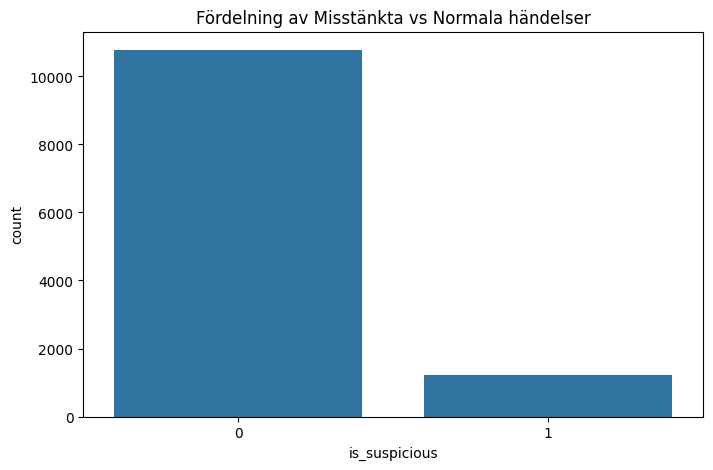

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(x='is_suspicious', data=df)
plt.title('Fördelning av Misstänkta vs Normala händelser')
plt.show()

Vårt dataset är obalanserat.
Om vi gissar att alla är hederliga har vi 90 % rätt, men vi stoppar 0 % av bedrägerierna.
Vi måste därför prioritera Precision (för att inte flagga oskyldiga i onödan).

In [20]:
missing_data = df.isnull().sum().sort_values(ascending=False)
print("\n--- Antal saknade värden per kolumn ---")
print(missing_data[missing_data > 0])



--- Antal saknade värden per kolumn ---
price                         818
time_to_first_response_min    590
region                        340
dtype: int64


In [21]:
print(df["region"].value_counts(dropna=False))

region
metro    5219
urban    4095
rural    2346
NaN       340
Name: count, dtype: int64


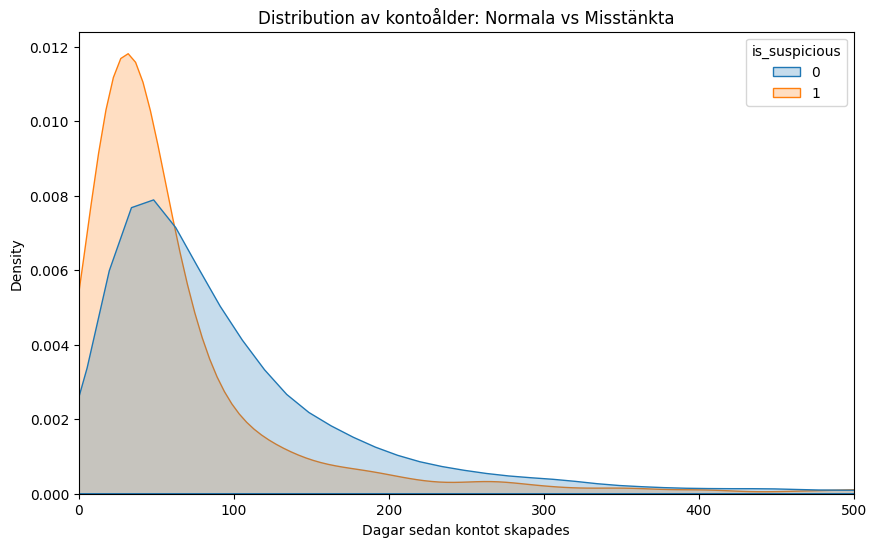

In [22]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='account_age_days', hue='is_suspicious', common_norm=False, fill=True)
plt.title('Distribution av kontoålder: Normala vs Misstänkta')
plt.xlabel('Dagar sedan kontot skapades')
plt.xlim(0, 500)
plt.show()

Vi ser en tydlig 'peak' för misstänkta händelser bland nyskapade konton (under 30 dagar). Detta kan var en kritisk signal för modellen. Äldre konton är generellt sett mycket säkrare.

## Pipeline

In [23]:
target_name = "is_suspicious"
X = df.drop(columns=[target_name,"id"])
y = df[target_name]

# make numeric/category feature
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["string"]).columns.tolist()


X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("numeric_features :", numeric_features)
print("\ncategorical_features :", categorical_features)

numeric_features : ['day', 'account_age_days', 'num_prev_listings', 'prev_reports_30d', 'verification_level', 'price', 'num_images', 'message_length', 'contains_off_platform', 'urgency_words', 'payment_attempt', 'time_to_first_response_min']

categorical_features : []


## Pipeline

In [24]:



numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)

    ],
    remainder="drop"
)


### Modeller 

### Baseline


In [58]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),    
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0)
}

dummy_model = DummyClassifier(strategy="constant", constant=1, random_state=42)
dummy_model.fit(X_train, y_train)


dummy_scores = cross_validate(dummy_model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)

dummy_df = pd.DataFrame(dummy_scores)
print("Dummy Model Scores:")
print(dummy_df[["test_accuracy", "test_precision", "test_recall", "test_f1"]].mean())


dummy_model2 = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_model2.fit(X_train, y_train)


dummy_scores2 = cross_validate(dummy_model2, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)

dummy_df2 = pd.DataFrame(dummy_scores2)
print("Dummy Model Scores:")
print(dummy_df2[["test_accuracy", "test_precision", "test_recall", "test_f1"]].mean())



Dummy Model Scores:
test_accuracy     0.102024
test_precision    0.102024
test_recall       1.000000
test_f1           0.185157
dtype: float64
Dummy Model Scores:
test_accuracy     0.897976
test_precision    0.000000
test_recall       0.000000
test_f1           0.000000
dtype: float64


In [25]:
logistic= Pipeline([
    ("preprocessor", preprocess),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2500, random_state=42))
])


random_forest = Pipeline([
    ("preprocessor", preprocess),
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42))
])


decision_tree = Pipeline([
    ("preprocessor", preprocess),
    ("scaler", StandardScaler()),
    ("classifier", DecisionTreeClassifier(random_state=42))
])


In [26]:
models = {
    "Logistic Regression": logistic,
    "Random Forest": random_forest,
    "Decision Tree": decision_tree
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Trained:", name)


Trained: Logistic Regression
Trained: Random Forest
Trained: Decision Tree


### Cross validation
The metric of interest is Precision
However, we also verify the performance of the models based on other metrics

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score),    
    "recall": make_scorer(recall_score),
    "f1": make_scorer(f1_score)
}

cv_results = {}
for name, model in models.items():
    cv_results[name] = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)


cv_summary = pd.DataFrame({
    name: {metric: result[f'test_{metric}'].mean() for metric in scoring.keys()}
    for name, result in cv_results.items()
}).T

print(cv_summary)




                     accuracy  precision    recall        f1
Logistic Regression  0.899405   0.601667  0.046695  0.086497
Random Forest        0.896429   0.425192  0.033864  0.062485
Decision Tree        0.829643   0.195410  0.214749  0.204536


### Best model 
Based on the results from cross validation, Logistic regression is the best model

In [29]:
Best_model = models["Logistic Regression"]
Best_model.fit(X_train, y_train)
y_pred = Best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))


Test Accuracy: 0.8983333333333333
Test Precision: 0.5238095238095238
Test Recall: 0.02997275204359673
Test F1 Score: 0.05670103092783505
